In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.count()

,0
Month,144
Passengers,144


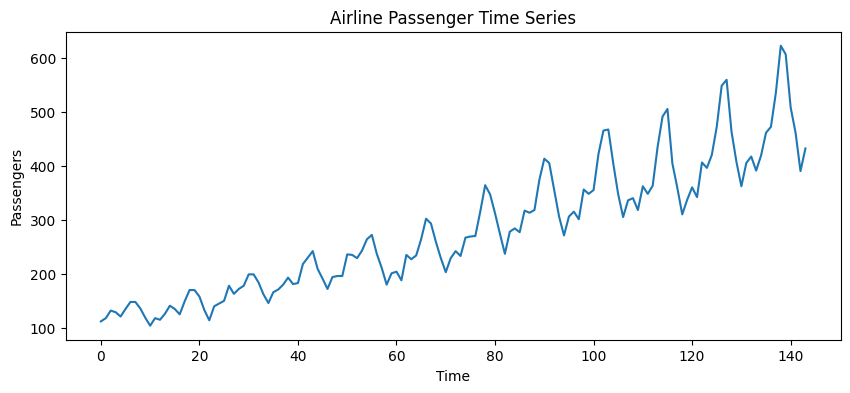

In [ ]:
data = df['Passengers'].values

plt.figure(figsize=(10,4))
plt.plot(data)
plt.title("Airline Passenger Time Series")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.show()

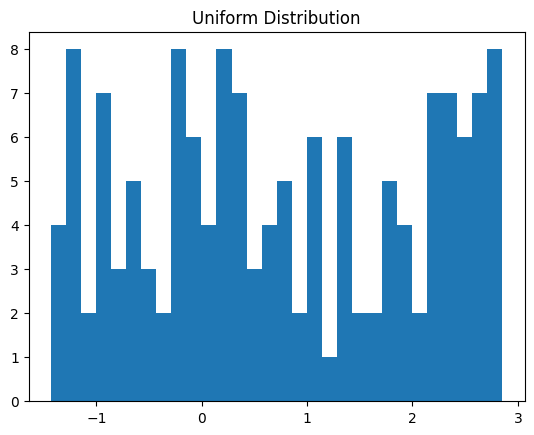

In [ ]:
uniform_data = np.random.uniform(min(data), max(data), len(data))

plt.hist(uniform_data, bins=30)
plt.title("Uniform Distribution")
plt.show()

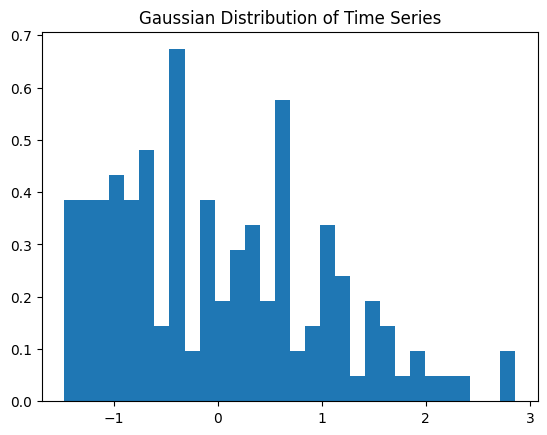

In [ ]:
plt.hist(data, bins=30, density=True)
plt.title("Gaussian Distribution of Time Series")
plt.show()

In [ ]:
data = (data - np.mean(data)) / np.std(data)

In [ ]:
window = 10

X = []
y = []

for i in range(len(data) - window):
    X.append(data[i:i+window])
    y.append(data[i+window])

X = np.array(X)
y = np.array(y)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1,1)

In [ ]:
class FVSBN(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )

    def forward(self,x):
        return self.model(x)

model = FVSBN(window)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):

    pred = model(X)
    loss = criterion(pred,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print("Epoch:",epoch,"Loss:",loss.item())

Epoch: 0 Loss: 0.8451260328292847
Epoch: 10 Loss: 0.5323476791381836
Epoch: 20 Loss: 0.28184056282043457
Epoch: 30 Loss: 0.16591714322566986
Epoch: 40 Loss: 0.14644725620746613
Epoch: 50 Loss: 0.11553260684013367
Epoch: 60 Loss: 0.09271212667226791
Epoch: 70 Loss: 0.0773218423128128
Epoch: 80 Loss: 0.06666465103626251
Epoch: 90 Loss: 0.05598800256848335


In [ ]:
generated = list(data[:window])

for i in range(100):

    inp = torch.tensor(generated[-window:],dtype=torch.float32).view(1,-1)

    next_val = model(inp).detach().numpy()[0][0]

    generated.append(next_val)

generated = np.array(generated)

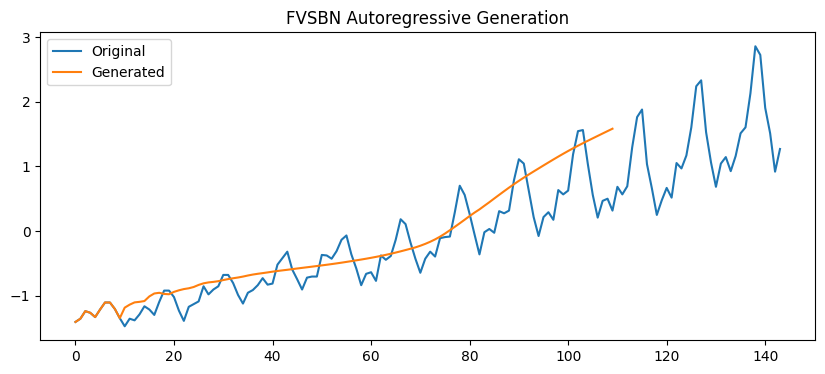

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(data,label="Original")
plt.plot(generated,label="Generated")

plt.legend()
plt.title("FVSBN Autoregressive Generation")
plt.show()